Libraries and helper functions:

In [2]:
import sys
import os
sys.path.append(os.path.abspath('../..')) 

import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pra
from scipy.signal import lfilter
from helpers.adaptSPM import adaptSPM

Simulation:

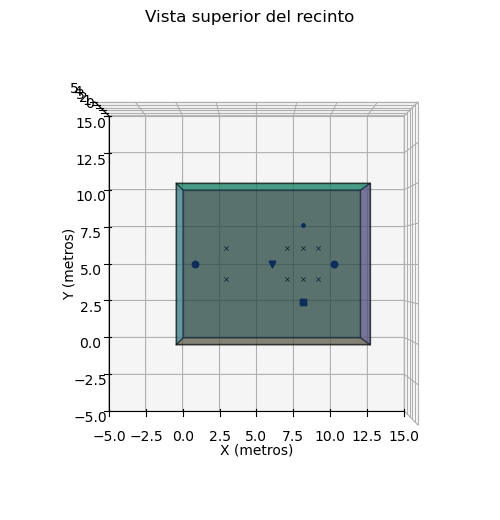

In [3]:
# Create a room
fs = 12000
room = pra.ShoeBox([12, 10, 5], fs=fs, max_order=0)

# Noise source
room.add_source([1, 5, 2.5])

# Reference microphones
room.add_microphone([3, 4, 2.5], fs=fs)
room.add_microphone([3, 6, 2.5], fs=fs)

# Actuators
room.add_source([8, 2.5, 2.5])
room.add_source([6, 5, 2.5])
room.add_source([8, 7.5, 2.5])
room.add_source([10, 5, 2.5])

# Error microphones
room.add_microphone([7, 4, 2.5], fs=fs)
room.add_microphone([7, 6, 2.5], fs=fs)
room.add_microphone([8, 4, 2.5], fs=fs)
room.add_microphone([8, 6, 2.5], fs=fs)
room.add_microphone([9, 4, 2.5], fs=fs)
room.add_microphone([9, 6, 2.5], fs=fs)

fig, ax = room.plot()
ax.view_init(elev=90, azim=-90)
ax.set_title("Vista superior del recinto")
ax.set_xlim(-5, 15)
ax.set_ylim(-5, 15)
plt.grid(True)
plt.xlabel('X (metros)')
plt.ylabel('Y (metros)')
plt.show()

Obtain RIRs:

In [4]:
nReferenceMics = 2
nActuators = 4
nErrorMics = 6

room.compute_rir()
referencePaths = [room.rir[m][0] for m in range(nReferenceMics)]
primaryPaths = [room.rir[m][0] for m in range(nReferenceMics, nReferenceMics + nErrorMics)]
secondaryPaths = [[room.rir[m][s] for s in range(1, nActuators + 1)] for m in range(nReferenceMics, nReferenceMics + nErrorMics)]

# Shape RIRs for efficient convolution
referencePaths = np.array([
    np.pad(h, (0, max(len(h) for h in referencePaths) - len(h)))
    for h in referencePaths
])

primaryPaths = np.array([
    np.pad(h, (0, max(len(h) for h in primaryPaths) - len(h)))
    for h in primaryPaths
])

maxLen = max(len(h) for row in secondaryPaths for h in row)
secondaryPaths = np.array([
    [np.pad(h, (0, maxLen - len(h))) for h in row]
    for row in secondaryPaths
])

print("Reference paths shape: ", referencePaths.shape)
print("Primary paths shape: ", primaryPaths.shape)
print("Secondary paths shape: ", secondaryPaths.shape)

Reference paths shape:  (2, 161)
Primary paths shape:  (6, 365)
Secondary paths shape:  (6, 4, 210)


Algorithm:

block: 0 actuator: 0 modelError: 0.9872256628536227
block: 50 actuator: 0 modelError: 0.10897805613577846
Actuator 0 converged in block number: 68
block: 100 actuator: 1 modelError: 0.2435811955452402
Actuator 1 converged in block number: 138
block: 150 actuator: 2 modelError: 0.59826926781619
block: 200 actuator: 2 modelError: 0.07021086716802236
Actuator 2 converged in block number: 209
block: 250 actuator: 3 modelError: 0.16234591130662077
Actuator 3 converged in block number: 277
All actuators identified.


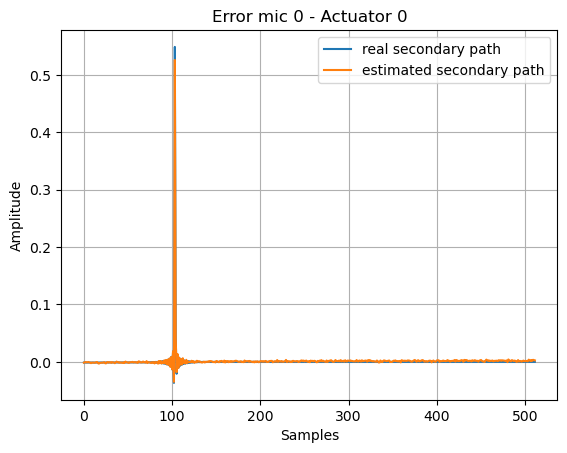

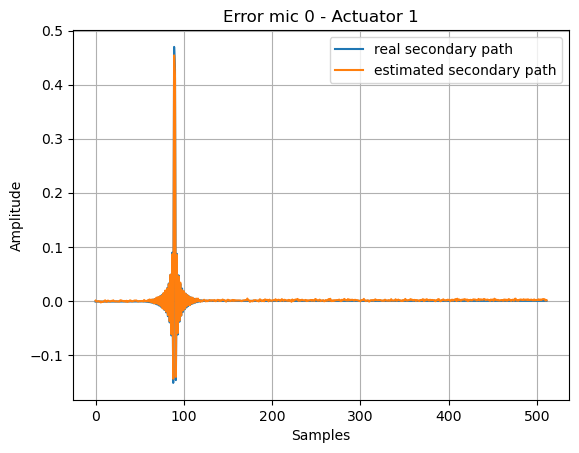

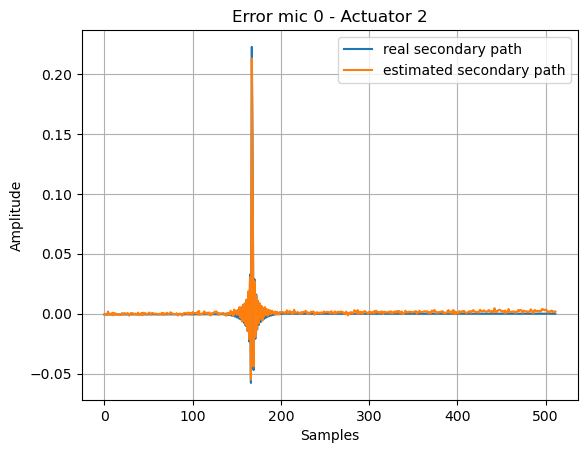

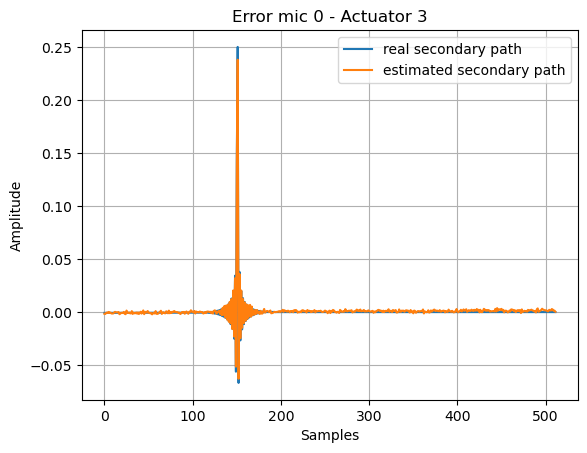

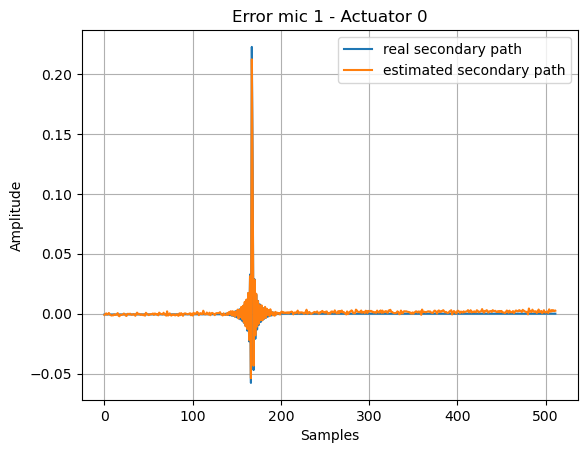

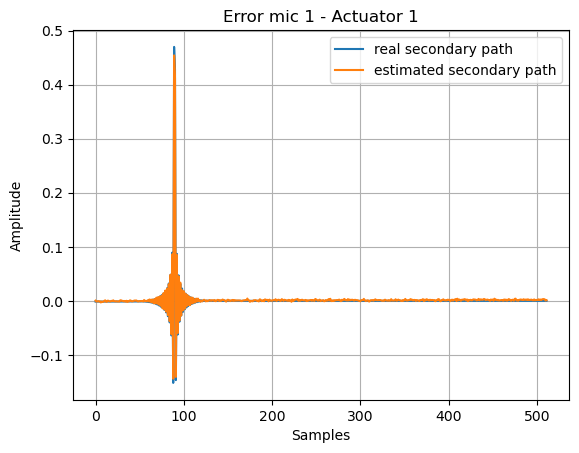

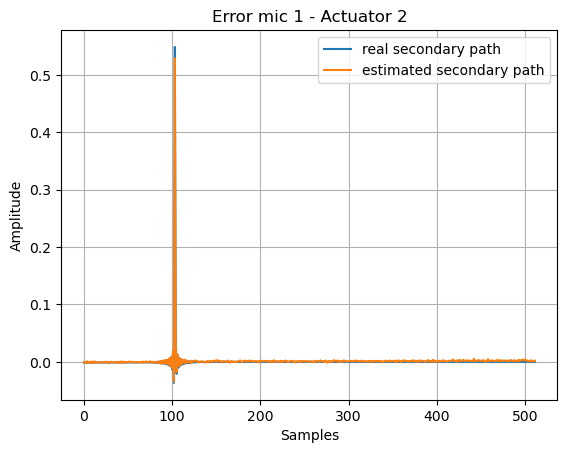

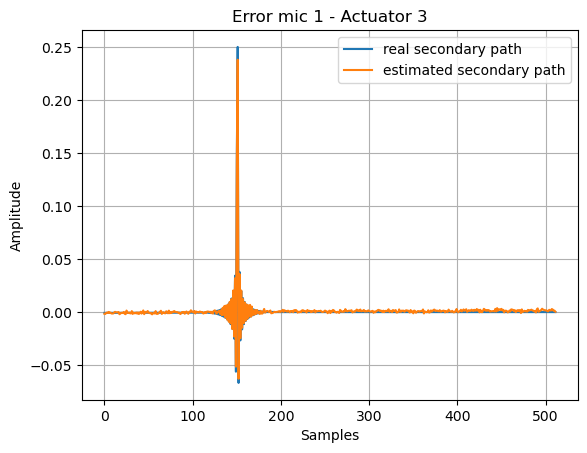

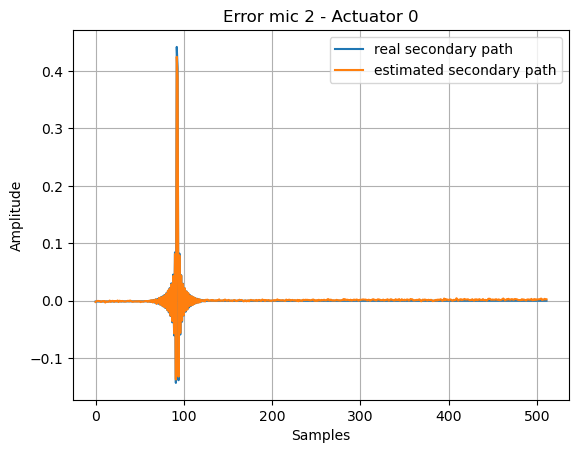

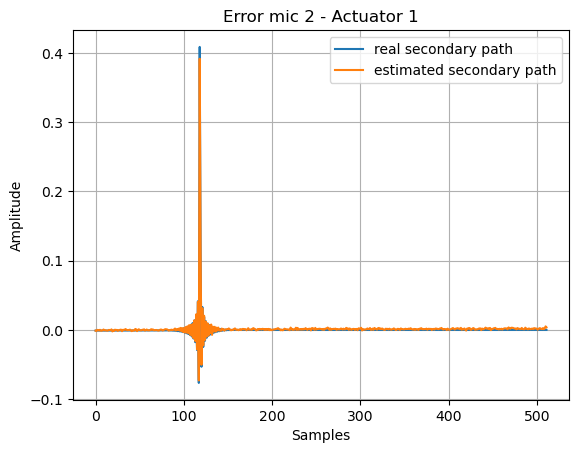

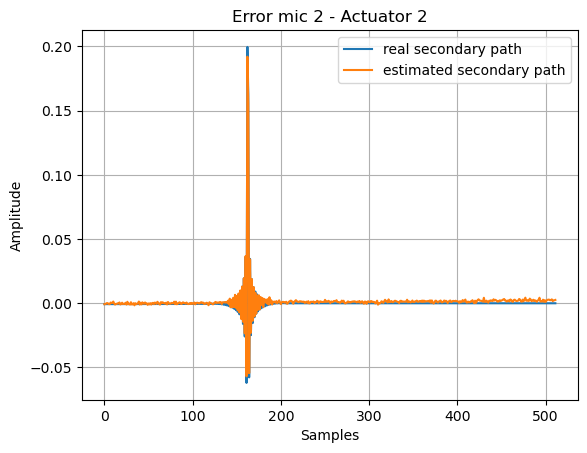

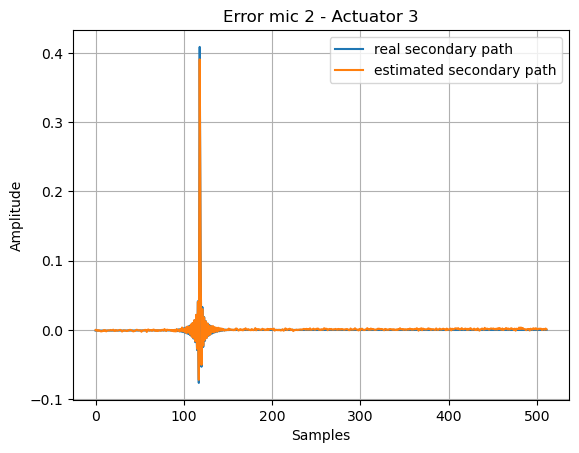

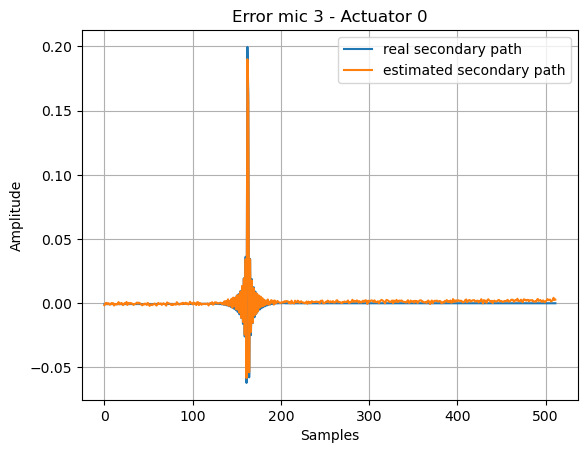

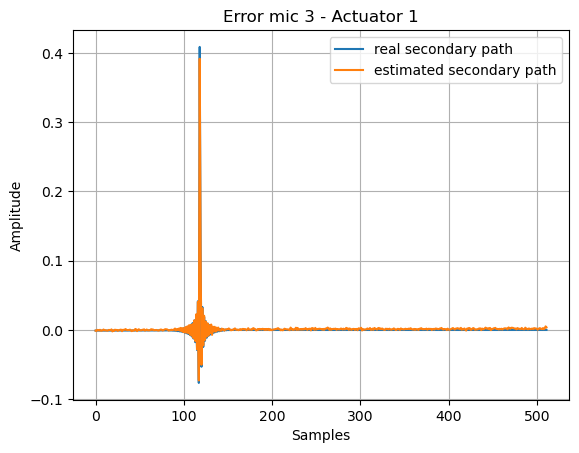

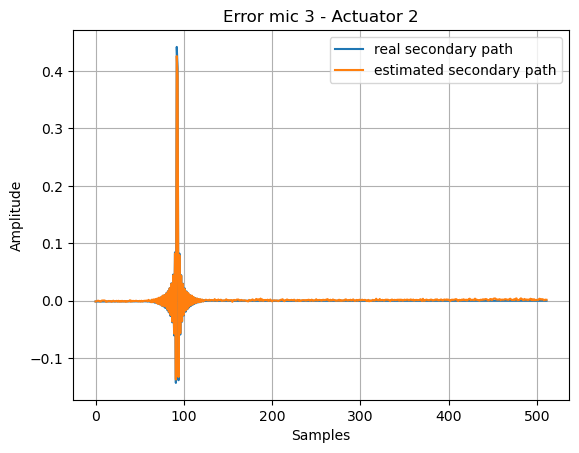

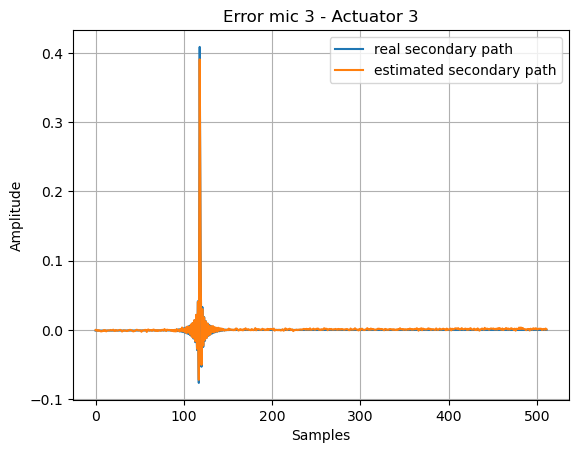

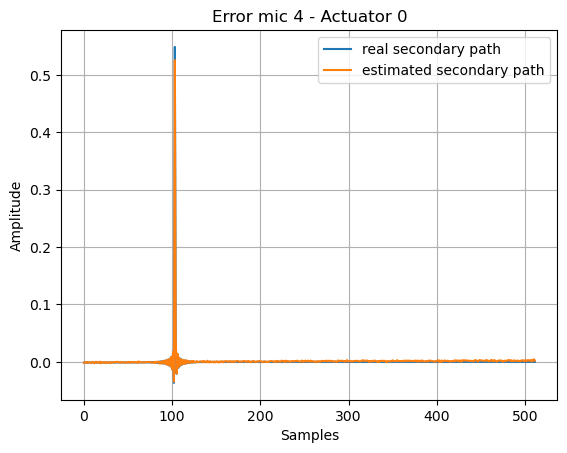

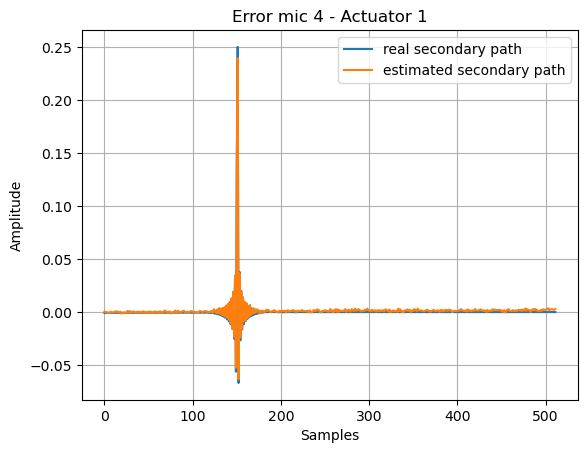

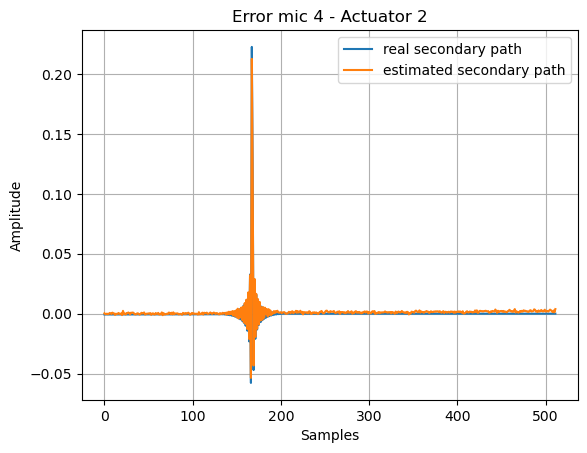

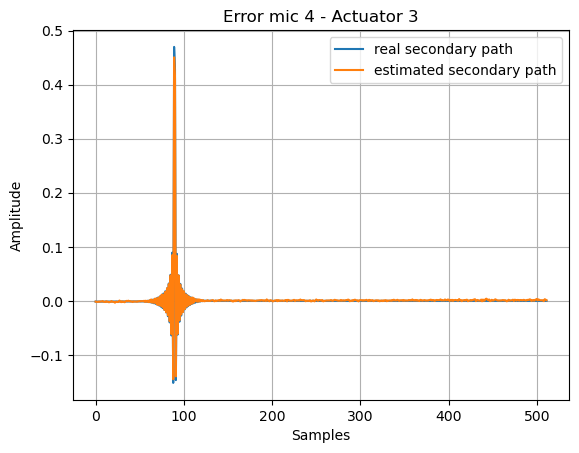

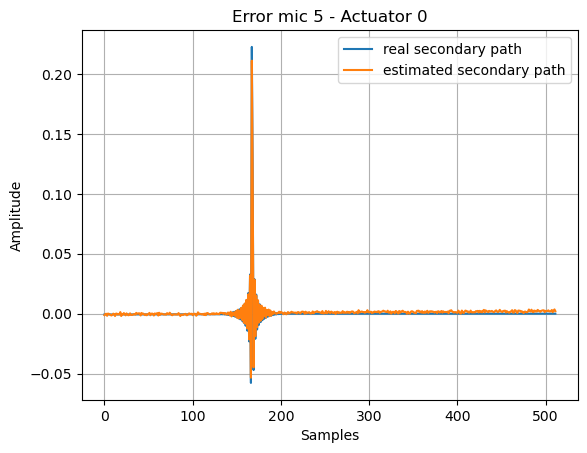

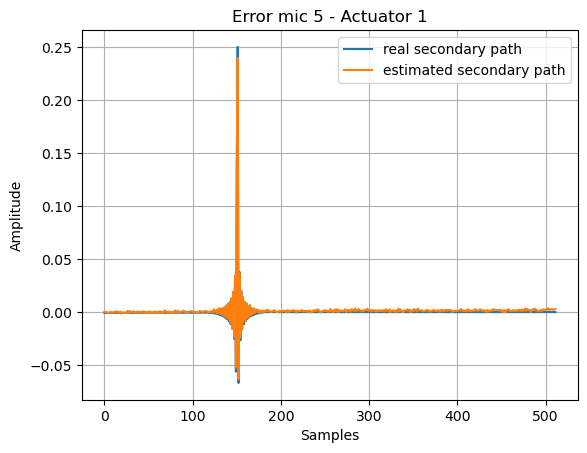

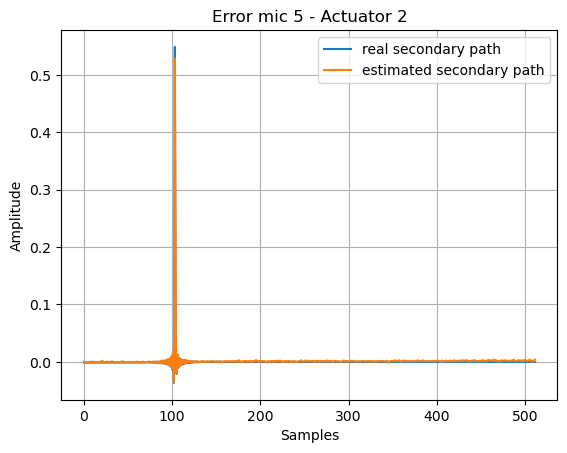

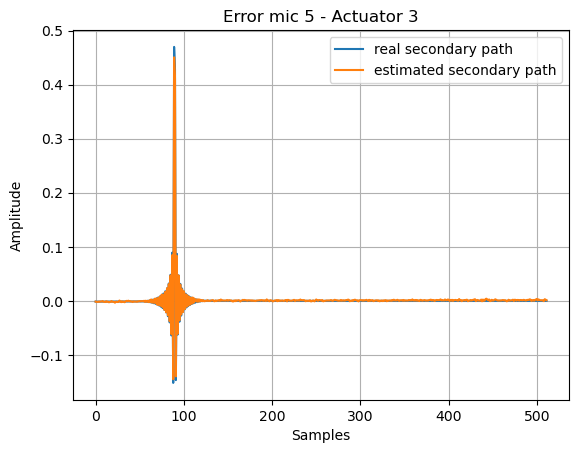

In [ ]:
# Disturbance
blocklength = 1024
nBlocks = 5000
N = nBlocks * blocklength
t = np.arange(N) * (1/fs)
x = np.random.randn(N)

# Identification noise initilization
identificationNoise = 5 * np.random.randn(N)

# Activated actuator variable to model one plant at a time
activatedActuator = 0

# Threshold to detect converged plant models
threshold = 0.05
thresholdWindow = 10

# Adaptive filter matrix definition
nTaps = 512
gHat = np.ones((nErrorMics, nActuators, nTaps)) * 0.01
mu = 0.05

# States for online time domain convolution
referenceStates = np.zeros((nReferenceMics, referencePaths.shape[1] - 1))
disturbanceStates = np.zeros((nErrorMics, primaryPaths.shape[1] - 1))
gHatOutputsStates = np.zeros((nErrorMics, nActuators, nTaps - 1))
controlStates = np.zeros((nErrorMics, nActuators, secondaryPaths.shape[2] - 1))
filteredReferencesStates = np.zeros((nErrorMics, nActuators, nReferenceMics, secondaryPaths.shape[2] - 1))

# Pad secondary paths for model comparihson
secondaryPathsPadded = np.zeros((nErrorMics, nActuators, nTaps))
plantLength = min(secondaryPaths.shape[2], nTaps)
secondaryPathsPadded[:, :, :plantLength] = secondaryPaths[:, :, :plantLength]

# For testing
xRef = np.zeros((nReferenceMics, N))
d = np.zeros((nErrorMics, N))
u = np.zeros((nActuators, N))
y = np.zeros((nErrorMics, N))
e = np.zeros((nErrorMics, N))

for k in range(nBlocks):
    # Block samples of X (simulation)
    xSignal = x[k*blocklength : (k+1)*blocklength]
    
    ################## Physical signals ##################
        
    # Disturbance signals (simulation)
    dSignals = np.zeros((nErrorMics, blocklength))
    for m in range(nErrorMics):
        dSignals[m], disturbanceStates[m] = lfilter(
            primaryPaths[m],
            [1],
            xSignal,            
            zi=disturbanceStates[m]
        )

    # Identification noise inyection
    identificationNoiseBlock = identificationNoise[k*blocklength : (k+1)*blocklength]
        
    # Actuators signals
    actuatorsSignals = np.zeros((nActuators, blocklength))
    actuatorsSignals[activatedActuator] = identificationNoiseBlock
    
    # Control and Errors signals (simulation)
    controlSignals = np.zeros((nErrorMics, nActuators, blocklength))
    for nError in range(nErrorMics):
        for nActuator in range(nActuators):
            controlSignals[nError][nActuator], controlStates[nError][nActuator] = lfilter(
                secondaryPaths[nError][nActuator],
                [1],
                actuatorsSignals[nActuator],
                zi=controlStates[nError][nActuator]
            )
    controlSignals = np.sum(controlSignals, axis=1)

    errorSignals = dSignals + controlSignals
    
    ################## Algorithm ##################

    # Compute the filtered identification noise matrix
    filteredIndentificationNoise = np.zeros((nErrorMics, blocklength))
    for nError in range(nErrorMics):
        filteredIndentificationNoise[nError], gHatOutputsStates[nError][activatedActuator] = lfilter(
        gHat[nError][activatedActuator],
        [1],
        identificationNoiseBlock,
        zi=gHatOutputsStates[nError][activatedActuator]
    )
    
    spmErrorSignals = errorSignals - filteredIndentificationNoise

    # LMS algorithm
    gHat = adaptSPM(
        identificationNoiseBlock,
        spmErrorSignals,
        nTaps,
        blocklength,
        gHat,
        activatedActuator,
        mu
    )

    # Calculate difference between secondary path and the model
    modelError = np.linalg.norm(
        secondaryPaths[:, activatedActuator, :plantLength] - gHat[:, activatedActuator, :plantLength]
    ) / np.linalg.norm(
        secondaryPaths[:, activatedActuator, :plantLength]
    )

    if k % 50 == 0:
        print("block:", k, "actuator:", activatedActuator, "modelError:", modelError)

    if k > thresholdWindow and modelError < threshold:
        print(f"Actuator {activatedActuator} converged in block number:", k)
        activatedActuator += 1

        if activatedActuator >= nActuators:
            print("All actuators identified.")
            break
    
    ################## For testing ##################
    start = k * blocklength
    end = (k + 1) * blocklength

for nError in range(nErrorMics):
    for nActuator in range(nActuators):
        plt.figure()

        plt.plot(
            secondaryPathsPadded[nError, nActuator],
            label="real secondary path"
        )

        plt.plot(
            gHat[nError, nActuator],
            label="estimated secondary path"
        )

        plt.title(f"Error mic {nError} - Actuator {nActuator}")
        plt.xlabel("Samples")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid()
        plt.show()
